In [ ]:
import pandas as pd
import os
from functools import reduce
import matplotlib.pyplot as plt

def merge_csv_files(directory):

    df_list = []
    

    for filename in os.listdir(directory):
        if filename.endswith(".csv"):

            file_path = os.path.join(directory, filename)
            

            err_number = filename.split('_')[1].split('.')[0]  # Assumes format "reference_ERRXXXX.csv"
            
            df = pd.read_csv(file_path)
            

            if 'POS' in df.columns and 'REF' in df.columns:

                df = df[['POS', 'REF']]
                
                # Set the index to 'POS'
                df.set_index('POS', inplace=True)
                
                
                df.rename(columns={'REF': err_number}, inplace=True)
                
                
                df_list.append(df)
            else:
                print(f"No 'POS' or 'REF' column in {filename}")
        else:
            continue

    # Merge all dataframes on the index 'POS'
    if df_list:
        # Use reduce to merge all dataframes in the list on their index
        combined_df = reduce(lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how='outer'), df_list)
        
        return combined_df
    else:
        return pd.DataFrame()  

directory = "/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/outputs/src_outputs/indiv_ref_genome"

combined_df = merge_csv_files(directory)

print(combined_df)

In [33]:
import matplotlib.pyplot as plt

In [6]:
display(combined_df)

,ERR3989050,ERR3989044,ERR3241788,ERR3989078,ERR3989093,ERR3243148,ERR3242530,ERR3242524,ERR3989087,ERR3241763,...,ERR3989263,ERR3989277,ERR3239366,ERR3242924,ERR3242930,ERR3242501,ERR3241752,ERR3989061,ERR3989075,ERR3989049
POS,,,,,,,,,,,,,,,,,,,,,
1,G,G,G,G,G,G,G,G,G,G,...,G,G,G,G,G,G,G,G,G,G
2,C,C,C,C,C,C,C,C,C,C,...,C,C,C,C,C,C,C,C,C,C
3,T,T,T,T,T,T,T,T,T,T,...,T,T,T,T,T,T,T,T,T,T
4,G,G,G,G,G,G,G,G,G,G,...,G,G,G,G,G,G,G,G,G,G
5,A,A,A,A,A,A,A,A,A,A,...,A,A,A,A,A,A,A,A,A,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13310,T,T,T,T,T,T,T,T,T,T,...,T,T,T,T,T,T,T,T,T,T
13311,C,C,C,C,C,C,C,C,C,C,...,C,C,C,C,C,C,C,C,C,C
13312,G,G,G,G,G,G,G,G,G,G,...,G,G,G,G,G,G,G,G,G,G


In [44]:
unique_counts = combined_df.apply(lambda x: x.nunique(), axis=1) #sanity check

print(unique_counts.max())

4


In [9]:
combined_df.isnull().values.any() #no null values

False

In [19]:
# Ensure 'POS' is not set as an index; if it is, reset it first:
if 'POS' in combined_df.index.names:
    combined_df.reset_index(inplace=True)

# Calculate the mode for each position
combined_df['1000_genome_new_ref'] = combined_df.mode(axis=1).iloc[:, 0]

most_common_patterns = combined_df[['POS', '1000_genome_new_ref']]

In [20]:
display(most_common_patterns)

,POS,1000_genome_new_ref
0,1,G
1,2,C
2,3,T
3,4,G
4,5,A
...,...,...
13309,13310,T
13310,13311,C
13311,13312,G
13312,13313,C


In [16]:
most_common_patterns.shape

(13314, 2)

In [27]:
#TODO:find how long the new reference is
concatenated_string = ''.join(most_common_patterns.iloc[:, 1])

In [29]:
len(concatenated_string)

13389

In [23]:
# most_common_patterns.to_csv("1000_genome_new_ref.csv")

In [37]:
# Analysis of insertions
most_common_patterns[most_common_patterns['1000_genome_new_ref'].str.len() > 1].shape

(42, 2)

/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_51312/2960155152.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insertion_data['position_bucket'] = insertion_data['POS'] // 1000 * 1000


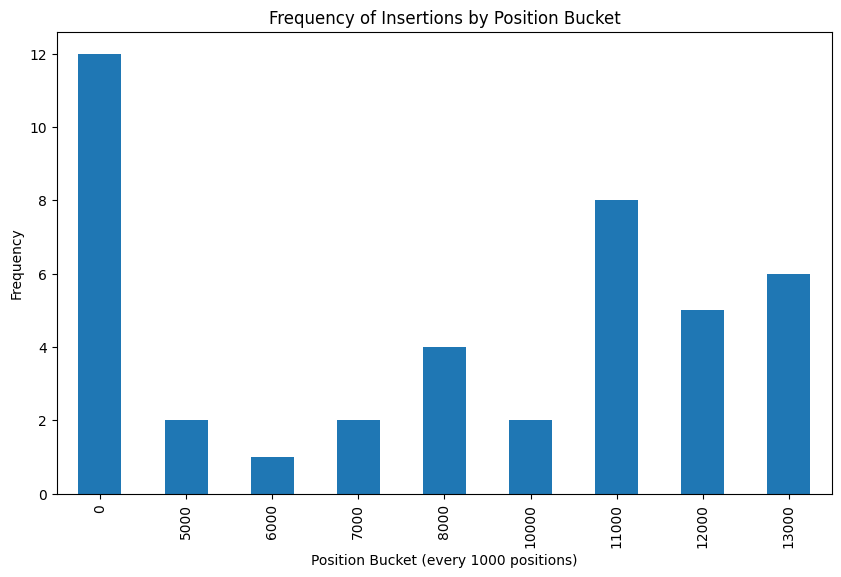

In [39]:
insertion_data = most_common_patterns[most_common_patterns['1000_genome_new_ref'].str.len() > 1]

insertion_data['position_bucket'] = insertion_data['POS'] // 1000 * 1000

bucket_counts = insertion_data['position_bucket'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bucket_counts.plot(kind='bar')
plt.title('Frequency of Insertions by Position Bucket')
plt.xlabel('Position Bucket (every 1000 positions)')
plt.ylabel('Frequency')
plt.show()